In [1]:
datasets_folder = "datasets/csvs/"
graphs_folder = "graphs/"
measures_folder = "measures/"
plots_folder = "plots/latex/"

# Horas críticas (Beiró & Gandica et al.)
HORA_CRITICA_NAT, HORA_CRITICA_9N, HORA_CRITICA_CH = "429624", "437037", "394717"
hour_window_nat, hour_window_9n, hour_window_ch = 1, 2, 2

limites = True

In [2]:
import os
from collections import Counter, defaultdict
from math import comb

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from networkx.algorithms.community import louvain_communities
from tqdm.auto import tqdm

plt.style.use("seaborn-v0_8-colorblind")

try:
    from sklearn.metrics import adjusted_mutual_info_score
except ImportError:
    def _entropy_from_labels(labels):
        n = len(labels)
        counts = Counter(labels)
        return -sum((c / n) * np.log(c / n) for c in counts.values())

    def _contingency_matrix(y_true, y_pred):
        classes_true = {c: i for i, c in enumerate(np.unique(y_true))}
        classes_pred = {c: i for i, c in enumerate(np.unique(y_pred))}
        cont = np.zeros((len(classes_true), len(classes_pred)), dtype=np.float64)
        for t, p in zip(y_true, y_pred):
            cont[classes_true[t], classes_pred[p]] += 1
        return cont

    def _expected_mutual_information(contingency):
        n = contingency.sum()
        if n == 0:
            return 0.0
        row_sum = contingency.sum(axis=1)
        col_sum = contingency.sum(axis=0)
        emi = 0.0
        for i in range(contingency.shape[0]):
            for j in range(contingency.shape[1]):
                n_ij = contingency[i, j]
                if n_ij == 0:
                    continue
                emi += (n_ij / n) * np.log(
                    (n * n_ij) / (row_sum[i] * col_sum[j] + 1e-12)
                )
        return emi

    def adjusted_mutual_info_score(y_true, y_pred):
        y_true = np.asarray(y_true)
        y_pred = np.asarray(y_pred)
        cont = _contingency_matrix(y_true, y_pred)
        n = cont.sum()
        if n == 0:
            return 1.0
        outer = np.outer(cont.sum(axis=1), cont.sum(axis=0))
        mi = 0.0
        for i in range(cont.shape[0]):
            for j in range(cont.shape[1]):
                n_ij = cont[i, j]
                if n_ij == 0:
                    continue
                mi += (n_ij / n) * np.log((n * n_ij) / (outer[i, j] + 1e-12))
        emi = _expected_mutual_information(cont)
        h_true = _entropy_from_labels(y_true)
        h_pred = _entropy_from_labels(y_pred)
        normalizer = 0.5 * (h_true + h_pred)
        denom = normalizer - emi
        if abs(denom) < 1e-12:
            return 1.0 if np.array_equal(y_true, y_pred) else 0.0
        return (mi - emi) / denom

EPSILON_BASE = "epsilon_sq/"
LOUVAIN_SEED = 42

HOUR_RANGES = {
    "nat": (429576, 429672),
    "9n": (int(HORA_CRITICA_9N) - 72, int(HORA_CRITICA_9N) + 72),
    "ch": (int(HORA_CRITICA_CH) - 48, int(HORA_CRITICA_CH) + 48),
}

MANIFESTACIONES = {
    "nat": {"hora_critica": HORA_CRITICA_NAT, "hour_window": hour_window_nat},
    "9n": {"hora_critica": HORA_CRITICA_9N, "hour_window": hour_window_9n},
    "ch": {"hora_critica": HORA_CRITICA_CH, "hour_window": hour_window_ch},
}

PLOT_LIMITS_REL = {
    m: (
        (HOUR_RANGES[m][0] - int(cfg["hora_critica"])) / cfg["hour_window"],
        (HOUR_RANGES[m][1] - int(cfg["hora_critica"])) / cfg["hour_window"],
    )
    for m, cfg in MANIFESTACIONES.items()
}

os.makedirs(plots_folder, exist_ok=True)

/home/msuarez/Escritorio/self_similarity/main_branch/github/self-similarity-in-social-movements/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
def load_graph(manifestacion, hora):
    path = f"{EPSILON_BASE}{manifestacion}/{hora}/{hora}.edge"
    if not os.path.exists(path) or os.path.getsize(path) == 0:
        return None
    g = nx.read_edgelist(path, data=False)
    g.remove_edges_from(nx.selfloop_edges(g))
    return g


def louvain_partition(g, seed=LOUVAIN_SEED):
    if g is None or g.number_of_nodes() == 0:
        return {}
    communities = louvain_communities(g, seed=seed)
    partition = {}
    for idx, comm in enumerate(communities):
        for node in comm:
            partition[node] = idx
    return partition


def list_hours(manifestacion, hora_range=None):
    base = f"{EPSILON_BASE}{manifestacion}/"
    hours = []
    for name in os.listdir(base):
        if not name.isdigit():
            continue
        h = int(name)
        if hora_range is not None:
            h0, h1 = hora_range
            if h < h0 or h >= h1:
                continue
        edge = f"{base}{name}/{name}.edge"
        if os.path.isfile(edge) and os.path.getsize(edge) > 0:
            hours.append(name)
    return sorted(hours, key=int)


def labels_for_ami(partition_ref, partition_h, nodes):
    labels_ref = [partition_ref[n] for n in nodes]
    max_h = max(partition_h.values(), default=-1)
    labels_h = []
    next_singleton = max_h + 1
    for n in nodes:
        if n in partition_h:
            labels_h.append(partition_h[n])
        else:
            labels_h.append(next_singleton)
            next_singleton += 1
    return labels_ref, labels_h


def pairwise_comembership(partition_ref, partition_h, nodes):
    ref_clusters = defaultdict(list)
    for n in nodes:
        ref_clusters[partition_ref[n]].append(n)

    denom = sum(comb(len(members), 2) for members in ref_clusters.values())
    if denom == 0:
        return 1.0

    numer = 0
    for members in ref_clusters.values():
        by_h = defaultdict(int)
        for n in members:
            if n in partition_h:
                by_h[partition_h[n]] += 1
        numer += sum(comb(c, 2) for c in by_h.values())
    return numer / denom


def compute_metrics_for_manifestacion(manifestacion, cfg):
    hora_critica = cfg["hora_critica"]
    hour_window = cfg["hour_window"]

    g_ref = load_graph(manifestacion, hora_critica)
    if g_ref is None:
        raise FileNotFoundError(
            f"No se encontró el grafo de la hora crítica: {manifestacion}/{hora_critica}"
        )

    partition_ref = louvain_partition(g_ref)
    nodes_ref = list(partition_ref.keys())
    hora_critica_int = int(hora_critica)

    rows = []
    hora_range = HOUR_RANGES[manifestacion]
    for hora in tqdm(
        list_hours(manifestacion, hora_range=hora_range),
        desc=f"{manifestacion.upper()}",
    ):
        g_h = load_graph(manifestacion, hora)
        partition_h = louvain_partition(g_h) if g_h is not None else {}

        labels_ref, labels_h = labels_for_ami(partition_ref, partition_h, nodes_ref)
        ami = adjusted_mutual_info_score(labels_ref, labels_h)
        pairwise = pairwise_comembership(partition_ref, partition_h, nodes_ref)

        rows.append(
            {
                "manifestacion": manifestacion,
                "hour": int(hora),
                "hour_rel": (int(hora) - hora_critica_int) / hour_window,
                "ami": ami,
                "pairwise": pairwise,
            }
        )

    return pd.DataFrame(rows)

In [4]:
results = []
for manifestacion, cfg in MANIFESTACIONES.items():
    results.append(compute_metrics_for_manifestacion(manifestacion, cfg))

df_ami = pd.concat(results, ignore_index=True)
df_ami.to_csv(f"{measures_folder}ami_louvain_vs_critica.csv", index=False)
df_ami.head()

CH: 100%|██████████| 91/91 [00:03<00:00, 26.96it/s]


,manifestacion,hour,hour_rel,ami,pairwise
0,nat,429576,-48.0,0.0,0.003123
1,nat,429577,-47.0,0.0,0.002541
2,nat,429578,-46.0,0.0,0.004288
3,nat,429579,-45.0,0.0,0.002594
4,nat,429580,-44.0,0.0,0.000900


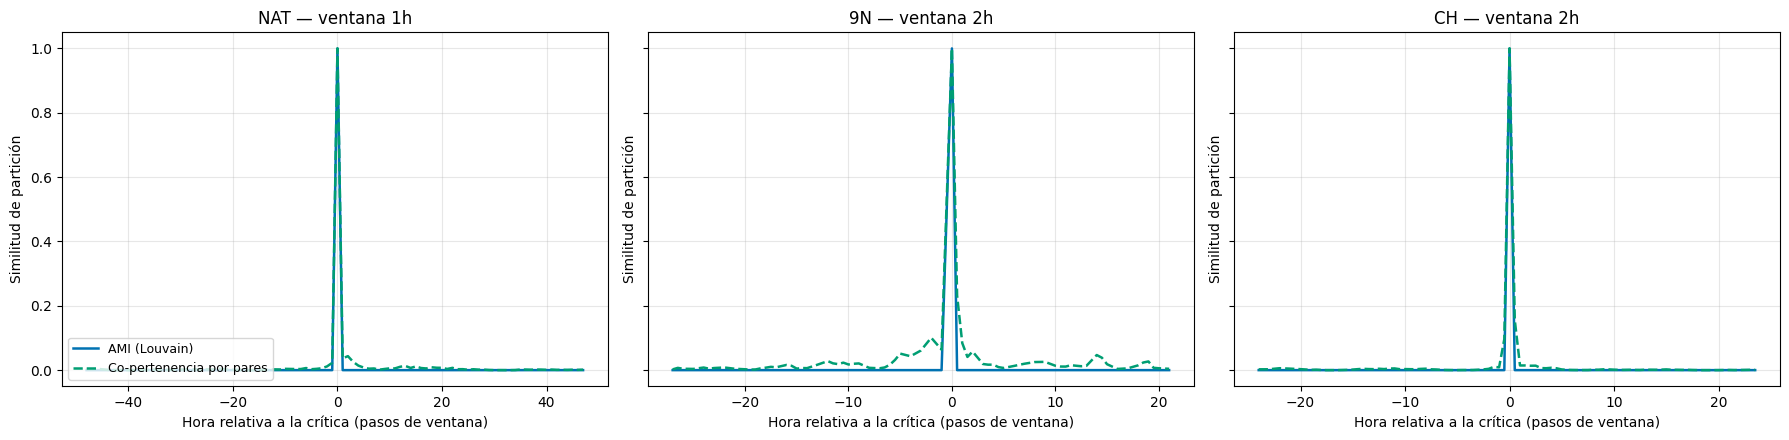

Guardado en plots/latex/ami_louvain_vs_critica.png


In [5]:
plot_frames = []
for manifestacion, cfg in MANIFESTACIONES.items():
    df_m = df_ami[df_ami["manifestacion"] == manifestacion].sort_values("hour_rel")

    if limites:
        h_min, h_max = PLOT_LIMITS_REL[manifestacion]
        df_m = df_m[(df_m["hour_rel"] >= h_min) & (df_m["hour_rel"] <= h_max)]

    df_m = df_m[df_m["hour_rel"] != 0]
    plot_frames.append((manifestacion, cfg, df_m))

ymax = max(
    max(df_m["ami"].max(), df_m["pairwise"].max())
    for _, _, df_m in plot_frames
) * 1.15

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5), sharey=True)

for ax, (manifestacion, cfg, df_m) in zip(axes, plot_frames):
    hour_window = cfg["hour_window"]

    ax.plot(df_m["hour_rel"], df_m["ami"], label="AMI (Louvain)", linewidth=1.8)
    ax.plot(
        df_m["hour_rel"],
        df_m["pairwise"],
        label="Co-pertenencia por pares",
        linewidth=1.8,
        linestyle="--",
    )

    ax.set_title(f"{manifestacion.upper()} — ventana {hour_window}h")
    ax.set_xlabel("Hora relativa a la crítica (pasos de ventana)")
    ax.set_ylabel("Similitud de partición")
    ax.set_ylim(0, ymax)
    ax.grid(alpha=0.3)

axes[0].legend(loc="upper right", fontsize=9)
plt.tight_layout()

out_path = f"{plots_folder}ami_louvain_vs_critica.png"
plt.savefig(out_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Guardado en {out_path}")